In [4]:
import statsmodels.formula.api as sm
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import logit, ols


FAMS = {
    1: 'Bear',
    2: 'Bunny',
    3: 'Green monster',
    4: 'Squid'
}

# Load data

In [5]:
DF = pd.read_csv('data/Mar2023/combined_filtered.csv')
DF = DF[~DF.fSumGt7]
display(DF)

,pid,condition,stage,feedbackOn,trialsComplete,famInd,features,rule,responseOrder,correctResponse,guess,confidence,correct,rt,fSumGt7,numTrainTrials,count
0,55d6e23469dbc30010b66dc3,free,epochs,True,1,4,"[4, 6]",fi,"[6, 7]",7,6,0.27,False,14236,False,180,1
1,55d6e23469dbc30010b66dc3,free,epochs,True,2,1,"[4, 4]",fi,"[2, 0]",2,0,0.30,False,7542,False,180,1
2,55d6e23469dbc30010b66dc3,free,epochs,True,3,3,"[3, 3]",fi,"[3, 5]",3,5,0.24,False,7085,False,180,1
3,55d6e23469dbc30010b66dc3,free,epochs,True,4,4,"[5, 3]",fi,"[6, 7]",7,7,1.00,True,5589,False,180,1
4,55d6e23469dbc30010b66dc3,free,epochs,True,5,1,"[5, 1]",fi,"[2, 0]",0,2,1.00,False,4555,False,180,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107218,64011d89460937cf59669000,interleaved,test2,False,86,4,"[4, 1]",fi,"[7, 6]",6,7,0.67,False,465,False,180,1
107219,64011d89460937cf59669000,interleaved,test2,False,87,3,"[2, 6]",fi,"[5, 3]",5,3,0.50,False,658,False,180,1
107220,64011d89460937cf59669000,interleaved,test2,False,88,4,"[3, 3]",fi,"[6, 7]",6,6,0.55,True,538,False,180,1
107221,64011d89460937cf59669000,interleaved,test2,False,89,1,"[1, 4]",fi,"[2, 0]",0,2,0.73,False,526,False,180,1


# Group-level learning curves (split by family)

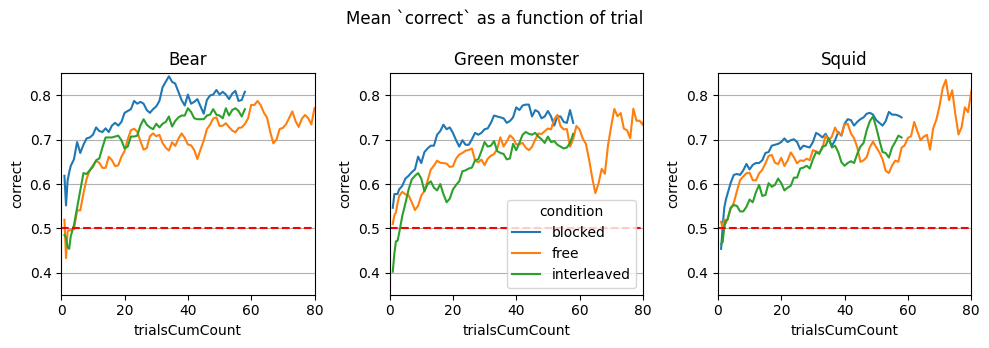

In [3]:
def learning_curves_split(df, v, smooth=1, save_as=''):
    df = df.query('stage == "epochs"')[['condition', 'famInd', 'trialsComplete', v, 'pid']]
    df['trialsCumCount'] = (df.groupby(['pid', 'famInd']).cumcount() + 1).astype(int)
    df = df.groupby(['condition', 'famInd', 'trialsCumCount']).mean().reset_index()
    df = df.groupby(['condition', 'famInd']).rolling(smooth, min_periods=1).mean().reset_index()
    # display_(df)
    fig = plt.figure(figsize=[10, 3.5])
    for i, fam in enumerate([1, 3, 4]):
        ax = fig.add_subplot(1, 3, i+1)
        ax.set_ylim(0.35, .85)
        ax.set_xlim(0, 80)
        plotdf = df[df.famInd.eq(fam)]
        sns.lineplot(x='trialsCumCount', y=v, hue='condition', data=plotdf, ax=ax, err_kws=dict(alpha=.5))
        ax.axhline(0.5, ls='--', color='r')
        ax.grid(axis='y')
        ax.set_title(f'{FAMS[fam]}')
        # ax.axvline(60)
        if i != 1:
            ax.get_legend().remove()
    fig.suptitle(f'Mean `{v}` as a function of trial')
    fig.tight_layout()

    if save_as:
        plt.savefig(save_as)


learning_curves_split(DF, v='correct', smooth=5, save_as='')

# Simple proportion correct across time during practice (aggregated across families)

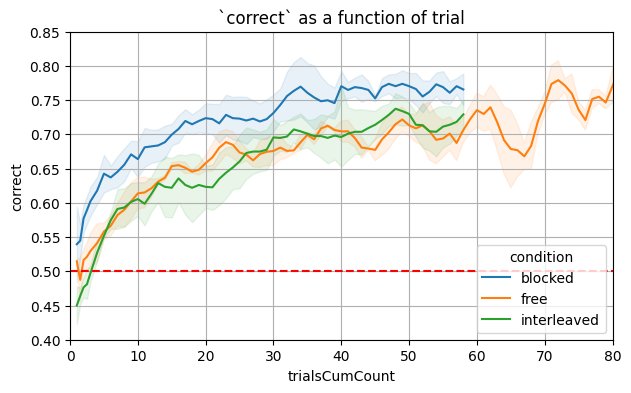

In [5]:
def learning_curves_agg(df, v='correct', save_as=''):
    df = df.query('stage == "epochs"').filter(items=['condition', 'famInd', 'trialsComplete', v, 'pid'])
    df['trialsCumCount'] = (df.groupby(['pid', 'famInd']).cumcount() + 1).astype(int)
    df = df.groupby(['condition', 'famInd', 'trialsCumCount']).mean().reset_index()
    df = df.groupby(['condition', 'famInd']).rolling(5, min_periods=1).mean().reset_index()
    
    fig, ax = plt.subplots(figsize=[7, 4])

    ax.set_ylim(0.40, .85)
    ax.set_xlim(0, 80)

    sns.lineplot(x='trialsCumCount', y=v, hue='condition', data=df, ax=ax, err_kws=dict(alpha=.1), errorbar=('ci', 90))
    ax.axhline(0.5, ls='--', color='r')
    ax.grid()
    plt.title(f'`{v}` as a function of trial')

    if save_as:
        plt.savefig(save_as)


learning_curves_agg(DF, v='correct')

# Test 1 and 2 performance

ANOVA: effect of `condition` on `correct` during test 1


,sum_sq,df,F,PR(>F)
condition,0.049982,2.0,2.932739,0.054806
Residual,2.513784,295.0,NaN,NaN


ANOVA: effect of `condition` on accuracy during test 2


,sum_sq,df,F,PR(>F)
condition,0.165806,2.0,7.252071,0.000842
Residual,3.372327,295.0,NaN,NaN


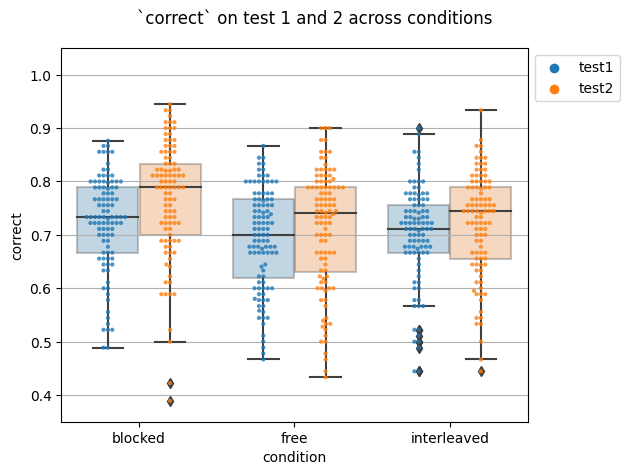

In [17]:
def pre_post_tests(df, v='correct', save_as=''):
    df = df.query('stage != "epochs"').filter(items=['condition', 'famInd', 'trialsComplete', v, 'pid', 'stage'])
    df = df.groupby(['condition', 'pid', 'stage']).mean().reset_index()
    df = df.sort_values(by=['condition', 'pid', 'stage'])

    fig, ax = plt.subplots()
    sns.boxplot(x='condition', y=v, hue='stage', boxprops=dict(alpha=.3), data=df, ax=ax)
    sns.swarmplot(x='condition', y=v, hue='stage', dodge=True, data=df, ax=ax, alpha=.8, s=3)
    ax.set_ylim(0.35, 1.05)
    ax.grid(axis='y')

    h,l = ax.get_legend_handles_labels()
    plt.legend(h[2:], l[2:])
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    plt.suptitle(f'`{v}` on test 1 and 2 across conditions')
    fig.tight_layout()

    if save_as:
        plt.savefig(save_as)

v = 'correct'
pre_post_tests(DF, v)

df = DF.groupby(['pid', 'condition', 'stage'])[[v]].mean().reset_index()

print(f'ANOVA: effect of `condition` on `{v}` during test 1')
linmod = ols(f'{v} ~ condition', data=df.query('stage == "test1"')).fit()
anova_table = anova_lm(linmod, typ=2)
display(anova_table)

print('ANOVA: effect of `condition` on accuracy during test 2')
linmod = ols(f'{v} ~ condition', data=df.query('stage == "test2"')).fit()
anova_table = anova_lm(linmod, typ=2)
display(anova_table)

# Test 1 and 2 contrasts

ANOVA: effect of condition on difference in correct between test 1 and 2


,sum_sq,df,F,PR(>F)
condition,0.007873,2.0,1.062901,0.346771
Residual,1.092601,295.0,NaN,NaN


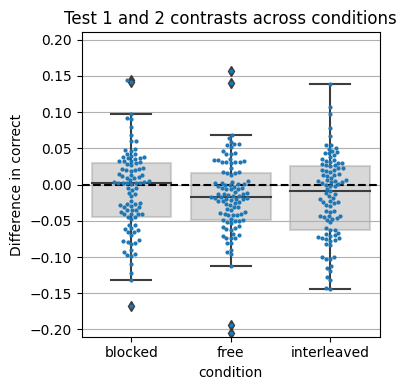

In [7]:
def test_contrasts(df, v, save_as=''):
    fig, ax = plt.subplots(figsize=[4, 4])
    sns.boxplot(y=v, x='condition', boxprops=dict(alpha=.3, color='gray'), data=df, ax=ax)
    sns.swarmplot(y=v, x='condition', dodge=True, data=df, ax=ax, s=3)
    ax.set_ylim(-0.21, 0.21)
    ax.axhline(0, ls='--', color='k')
    ax.set_ylabel(f'Difference in {v}')
    ax.grid(axis='y')
    plt.title('Test 1 and 2 contrasts across conditions')
    fig.tight_layout()

    if save_as:
        plt.savefig(f'plots/testsDiffPerCondition_{v}.png')


v = 'correct'
df = DF.query('stage != "epochs"').filter(items=['pid', 'condition', 'stage', v])
df = df.groupby(['condition', 'pid', 'stage']).mean().reset_index()
df = df.sort_values(by=['condition', 'pid', 'stage'])
df = df.groupby(['condition', 'pid'])[[v]].apply(lambda sdf: sdf.iloc[-1, :] - sdf.iloc[0, :]).reset_index()

test_contrasts(df, v)

linmod = ols(f'{v} ~ condition', data=df).fit()
anova_table = anova_lm(linmod, typ=2)
print(f'ANOVA: effect of condition on difference in {v} between test 1 and 2')
display(anova_table)


# Accuracy and confidence as a function of category boundary

,condition,pid,catBoundDist,famInd,trialsComplete,correct,f0,f1
0,blocked,565c40fbc121fe0005fc3b62,1,2.670588,76.623529,0.729412,3.482353,3.529412
1,blocked,565c40fbc121fe0005fc3b62,2,2.642857,76.014286,0.842857,3.528571,3.471429
2,blocked,565c40fbc121fe0005fc3b62,3,2.666667,79.666667,0.882353,3.470588,3.588235
3,blocked,565c40fbc121fe0005fc3b62,4,2.628571,74.885714,0.971429,3.571429,3.542857
4,blocked,565c40fbc121fe0005fc3b62,5,2.764706,77.529412,1.000000,3.647059,3.647059
...,...,...,...,...,...,...,...,...
1485,interleaved,64011d89460937cf59669000,1,2.701149,78.206897,0.540230,3.494253,3.517241
1486,interleaved,64011d89460937cf59669000,2,2.685714,74.900000,0.542857,3.528571,3.528571
1487,interleaved,64011d89460937cf59669000,3,2.645833,80.458333,0.458333,3.416667,3.333333
1488,interleaved,64011d89460937cf59669000,4,2.714286,65.028571,0.600000,3.542857,3.571429


Optimization terminated successfully.
         Current function value: 0.450793
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                correct   No. Observations:                 1490
Model:                          Logit   Df Residuals:                     1484
Method:                           MLE   Df Model:                            5
Date:                Mon, 15 May 2023   Pseudo R-squ.:                  -3.027
Time:                        13:54:35   Log-Likelihood:                -671.68
converged:                       True   LL-Null:                       -166.79
Covariance Type:            nonrobust   LLR p-value:                     1.000
============================================================================================================================================
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                    0.0658      0.244      0.269      0.788      -0.413       0.545
C(condition, Treatment(reference="blocked"))[T.free]                         0.0154      0.330      0.047      0.963      -0.632       0.663
C(condition, Treatment(reference="blocked"))[T.interleaved]                  0.0193      0.335      0.058      0.954      -0.637       0.676
catBoundDist                                                                 0.4484      0.086      5.212      0.000       0.280       0.617
catBoundDist:C(condition, Treatment(reference="blocked"))[T.free]           -0.1318      0.113     -1.168      0.243      -0.353       0.089
catBoundDist:C(condition, Treatment(reference="blocked"))[T.interleaved]    -0.1428      0.114     -1.252      0.210      -0.366       0.081
============================================================================================================================================
"""

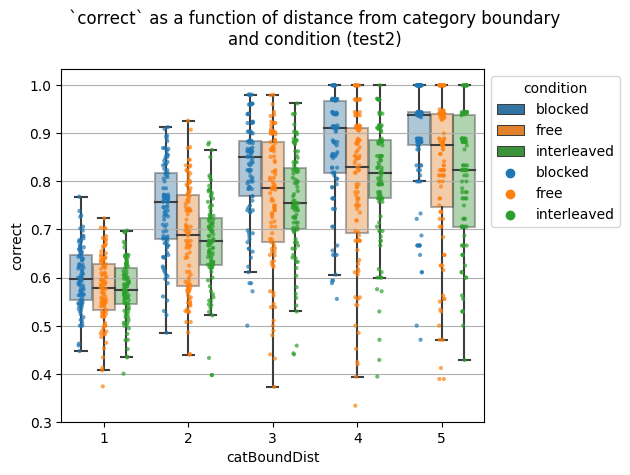

In [8]:
def cat_bound(df, v='correct', stage='test1', save_as=''):
    df = df.query('stage != @stage').filter(items=['condition', 'famInd', 'features', 'trialsComplete', v, 'pid', 'stage'])
    df = df.assign(
        f0 = df.features.str[1].astype(int),
        f1 = df.features.str[4].astype(int)
    )
    df = df.assign(
        catBoundDist = np.abs(df.f0 + df.f1 - 7),
    )

    df = df.groupby(['condition', 'pid', 'catBoundDist']).mean().reset_index()
    df = df.sort_values(by=['condition', 'pid'])

    fig, ax = plt.subplots()
    sns.boxplot(x='catBoundDist', y=v, hue='condition', data=df, ax=ax, boxprops=dict(alpha=.4), fliersize=0)
    # sns.lineplot(x='catBoundDist', y=v, hue='condition', data=df, ax=ax)
    sns.stripplot(x='catBoundDist', y=v, hue='condition', dodge=True, data=df, ax=ax, alpha=.7, s=3)
    ax.grid(axis='y')

    h,l = ax.get_legend_handles_labels()
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    plt.suptitle(f'`{v}` as a function of distance from category boundary\nand condition ({stage})')
    fig.tight_layout()

    if save_as:
        plt.savefig(save_as)


def cat_bound_model(df, v, stage, save_as):
    df = df.query('stage != @stage').filter(items=['condition', 'famInd', 'features', 'trialsComplete', v, 'pid', 'stage'])
    df = df.assign(
        f0 = df.features.str[1].astype(int),
        f1 = df.features.str[4].astype(int)
    )
    df = df.assign(
        catBoundDist = np.abs(df.f0 + df.f1 - 7),
    )

    df.to_csv('data/catboundstrials.csv', index=False)
    
    df = df.groupby(['condition', 'pid', 'catBoundDist']).mean().reset_index()
    df = df.sort_values(by=['condition', 'pid'])
    display(df)

    logmod = logit(f'{v} ~ catBoundDist * C(condition, Treatment(reference="blocked"))', data=df)
    results = logmod.fit()

    display(results.summary())
    df.to_csv('data/catbounds2.csv', index=False)
    # fig, ax = plt.subplots()
    # ax.grid(axis='y')
    # h,l = ax.get_legend_handles_labels()
    # sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    # plt.suptitle(f'`{v}` as a function of distance from category boundary\nand condition ({stage})')
    # fig.tight_layout()

    if save_as:
        plt.savefig(save_as)

v = 'correct'
s = 'test2'
cat_bound(DF, v, s, '')
cat_bound_model(DF, v, s, '')